## Grid Search for Analyzer Settings

Find optimal weights for the following measures:
 * bibliographic coupling (BC)
 * co-citations (CC)
 * direct citations (DC)
 * text citations (TC)

In [19]:
import json
import itertools
import logging
import os

from pysrc.papers.pubtrends_config import AnalyzerSettings

from sklearn.metrics.cluster import adjusted_rand_score, v_measure_score, \
                                    adjusted_mutual_info_score, contingency_matrix
from sklearn.metrics import fowlkes_mallows_score

from utils.analysis import reload_exported_analyzer, rebuild_similarity_graph, \
                           get_direct_references_subgraph, recalculate_topic_analysis, \
                           align_clusterings_for_sklearn
from utils.preprocessing import preprocess_clustering

In [2]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')

In [3]:
# TODO: use relative paths
CLUSTERING_FOLDER = '/home/willenjoy/work/pubtrends/nature_reviews/clustering/'
PUBTRENDS_EXPORT_FOLDER = '/home/willenjoy/work/pubtrends/nature_reviews/pubtrends_export/'

In [20]:
TARGET_METRIC = v_measure_score.__name__

In [4]:
def settings_of_interest(analyzer_settings):
    return (
        analyzer_settings.SIMILARITY_BIBLIOGRAPHIC_COUPLING,
        analyzer_settings.SIMILARITY_COCITATION,
        analyzer_settings.SIMILARITY_CITATION,
        analyzer_settings.SIMILARITY_TEXT_CITATION,
    )

In [24]:
def run_grid_search(analyzer, subgraph, ground_truth, baseline_params, param_grid):
    param_names = param_grid.keys()
    
    best_score = 0
    best_soi = None
    grid_results = {}
    
    # Iterate over param grid
    for param_values in itertools.product(*param_grid.values()):
        params = {k: v for k, v in zip(param_names, param_values)}
        for k, v in baseline_params.items():
            params[k] = v

        # Apply settings and recalculate 
        settings = AnalyzerSettings(**params)
        soi = settings_of_interest(settings)
        partition = recalculate_topic_analysis(analyzer, 
                                               graph=subgraph,
                                               settings=settings)
        labels_true, labels_pred = align_clusterings_for_sklearn(partition, ground_truth)
        
        result = {}
        for metric in [adjusted_rand_score, adjusted_mutual_info_score, 
                       v_measure_score, fowlkes_mallows_score]:
            result[metric.__name__] = metric(labels_true, labels_pred)

        result['partition'] = partition
        grid_results[soi] = result

        n_comps = len(set(partition.values()))
        new_best = False
        if result[TARGET_METRIC] > best_score:
            best_score = result[TARGET_METRIC]
            best_soi = soi
            new_best = True

        score_str = f"{'BEST' if new_best else '    '} {result[TARGET_METRIC]}" 
        print(soi, score_str, n_comps, sep='\t')
        
    return grid_results

In [6]:
PMID = '31937935'

In [7]:
def load_data(pmid, level):
    full_filename = os.path.join(CLUSTERING_FOLDER, f'{pmid}.json')
    with open(full_filename, 'r') as f:
        raw_clustering = json.load(f)
    analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
    analyzer = reload_exported_analyzer(analysis_file)
    logging.info(f'{pmid} - loaded clustering and analyzer')
    rebuild_similarity_graph(analyzer)
    logging.info(f'{pmid} - rebuilt similarity graph with scaling')
    ground_truth = preprocess_clustering(raw_clustering, level, 
                                         include_box_sections=False,
                                         uniqueness_method='unique_only')
    return analyzer, ground_truth

In [10]:
analyzer, ground_truth = load_data(PMID, 1)

2021-02-18 23:54:14,781 INFO: 31937935 - loaded clustering and analyzer
2021-02-18 23:54:14,786 INFO: Building corpus from 500 papers
2021-02-18 23:54:14,867 INFO: Corpus size: 4264 bytes
2021-02-18 23:54:35,900 INFO: Building papers similarity graph
2021-02-18 23:54:36,574 INFO: Citations based graph - 500 nodes and 72692 edges
2021-02-18 23:54:36,581 INFO: Built full similarity graph - 500 nodes and 72710 edges
2021-02-18 23:54:36,634 INFO: 31937935 - rebuilt similarity graph with scaling


In [34]:
baseline_params = dict(
    TOPIC_MIN_SIZE=0,
    TOPICS_MAX_NUMBER=500,
    SIMILARITY_CITATION=1,
    SIMILARITY_COCITATION=0
)

In [35]:
param_grid = {
    'SIMILARITY_BIBLIOGRAPHIC_COUPLING': [0, 0.015675, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8, 16, 32, 64, 128],
#     'SIMILARITY_COCITATION': [0.125, 0.25, 0.5, 1, 2, 4, 8],
#     'SIMILARITY_CITATION': [0.125, 0.25, 0.5, 1, 2, 4, 8],
    'SIMILARITY_TEXT_CITATION': [0, 0.015675, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8, 16, 32, 64, 128]
}

In [15]:
subgraph = get_direct_references_subgraph(analyzer, PMID)

In [36]:
results_no_cocitation = run_grid_search(analyzer, subgraph, ground_truth, baseline_params, param_grid)

(0, 0, 1, 0)	BEST 0.4051120036525508	21
(0, 0, 1, 0.015675)	     0.38906686813055436	22
(0, 0, 1, 0.03125)	     0.39476759774539255	22
(0, 0, 1, 0.0625)	BEST 0.41924392338682503	22
(0, 0, 1, 0.125)	     0.40988950310273703	20
(0, 0, 1, 0.25)	     0.3982490266788228	19
(0, 0, 1, 0.5)	     0.40286570464000493	20
(0, 0, 1, 1)	     0.41790597596833556	22
(0, 0, 1, 2)	BEST 0.42338364538518075	21
(0, 0, 1, 4)	     0.4205561736390132	29
(0, 0, 1, 8)	     0.4010122373392968	43
(0, 0, 1, 16)	     0.4091335374427755	54
(0, 0, 1, 32)	     0.41647538185644956	56
(0, 0, 1, 64)	     0.3986645887479254	56
(0, 0, 1, 128)	     0.4052094523461686	56
(0.015675, 0, 1, 0)	     0.39757758649745734	24
(0.015675, 0, 1, 0.015675)	     0.3988654414902852	21
(0.015675, 0, 1, 0.03125)	     0.40192541537051213	22
(0.015675, 0, 1, 0.0625)	     0.38949162474807725	21
(0.015675, 0, 1, 0.125)	     0.41269239705412614	23
(0.015675, 0, 1, 0.25)	     0.38567568078956266	22
(0.015675, 0, 1, 0.5)	     0.39936788177747484	1

(32, 0, 1, 0.125)	     0.26499354401324704	5
(32, 0, 1, 0.25)	     0.25318888939510487	5
(32, 0, 1, 0.5)	     0.2616265336343429	5
(32, 0, 1, 1)	     0.2619885550861555	5
(32, 0, 1, 2)	     0.2631609545237425	6
(32, 0, 1, 4)	     0.274857349562927	6
(32, 0, 1, 8)	     0.2947746578902988	9
(32, 0, 1, 16)	     0.3130946849100063	14
(32, 0, 1, 32)	     0.32801558363716493	15
(32, 0, 1, 64)	     0.33896877564551287	18
(32, 0, 1, 128)	     0.3545267054570998	24
(64, 0, 1, 0)	     0.26484381550657704	5
(64, 0, 1, 0.015675)	     0.26484381550657704	5
(64, 0, 1, 0.03125)	     0.26499354401324704	5
(64, 0, 1, 0.0625)	     0.26499354401324704	5
(64, 0, 1, 0.125)	     0.26499354401324704	5
(64, 0, 1, 0.25)	     0.25318888939510487	5
(64, 0, 1, 0.5)	     0.2616265336343429	5
(64, 0, 1, 1)	     0.2619885550861555	5
(64, 0, 1, 2)	     0.2658926909400607	6
(64, 0, 1, 4)	     0.26988486656853133	6
(64, 0, 1, 8)	     0.274857349562927	8
(64, 0, 1, 16)	     0.3175848801113286	15
(64, 0, 1, 32)	     0.31

In [31]:
cocitation_soi = (0, 1, 0, 0)
cocitation_partition = results[cocitation_soi]['partition']

In [68]:
citation_soi = (0, 0, 1, 0)
citation_partition = results_no_cocitation[citation_soi]['partition']

In [53]:
import numpy as np

param_range = [0.015675, 0.03125, 0.0625, 0.125, 0.25, 0.5, 1, 2, 4, 8, 16, 32, 64, 128]
n_params = len(param_range)
param_grid_array = np.zeros((n_params, n_params))   

In [54]:
param_idx = {param: i for i, param in enumerate(param_range)}

In [69]:
for soi in results_no_cocitation:
    bibcoupling, _, _, text_citation = soi
    if not bibcoupling or not text_citation:
        continue
    current_partition = results_no_cocitation[soi]['partition']
    labels_true, labels_pred = align_clusterings_for_sklearn(current_partition,
                                                             citation_partition)
    param_grid_array[param_idx[bibcoupling], param_idx[text_citation]] = v_measure_score(labels_true, labels_pred)

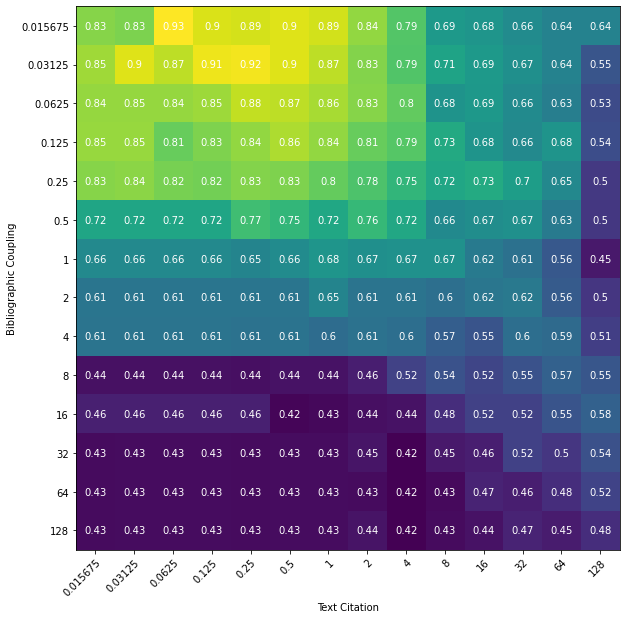

In [70]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(param_grid_array)

# We want to show all ticks...
ax.set_xticks(np.arange(n_params))
ax.set_yticks(np.arange(n_params))
# ... and label them with the respective list entries
ax.set_xticklabels(param_range)
ax.set_yticklabels(param_range)
ax.set_xlabel('Text Citation')
ax.set_ylabel('Bibliographic Coupling')

plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

for i in range(n_params):
    for j in range(n_params):
        display_value = round(param_grid_array[i, j], 2)
        text = ax.text(j, i, display_value,
                       ha="center", va="center", color="w")

In [42]:
scores_with_cocitations = {(k, v['v_measure_score']) for k, v in results.items()}
scores_without_cocitations = {(k, v['v_measure_score']) for k, v in results_no_cocitation.items()}

In [43]:
sorted(scores_without_cocitations, key=lambda el: el[1], reverse=True)[:5]

[((0.0625, 0, 1, 0.25), 0.4328264919880153),
 ((0.0625, 0, 1, 0.5), 0.42375554805271487),
 ((0.015675, 0, 1, 1), 0.423463098243007),
 ((0, 0, 1, 2), 0.42338364538518075),
 ((0.0625, 0, 1, 8), 0.42130157244573874)]